# **The example uses a synthetic medical scenario:**

*Predicting recovery time from medication dosage, where very low dosage may be ineffective and very high dosage may also increase recovery time because of side effects.*


---


This creates a curved relationship, making Polynomial Regression more suitable than simple Linear Regression.

# Polynomial Regression in a Clinical Domain

## Project Title

**Prediction of Patient Recovery Time Based on Medication Dosage**

## Domain

Clinical and Medical Data Analysis

## Main Objective

The objective of this notebook is to demonstrate Polynomial Regression using a synthetic clinical dataset.

The model will predict:

```text
Patient Recovery Time in Days

based on:

**Medication Dosage in Milligrams**

# **Important Note**

This dataset is artificially generated for educational purposes only.

***It must not be used for real medical diagnosis, treatment, dosage recommendation, or clinical decision-making.***


---

# Cell 2 — Markdown Cell

```markdown
## 1. What Is Polynomial Regression?

Polynomial Regression is a supervised machine learning algorithm used when the relationship between input and output is curved rather than a straight line.

Simple Linear Regression assumes:

```text
Y = b0 + b1X

**Polynomial Regression may use:**

Y = b0 + b1X + b2X²

or:

Y = b0 + b1X + b2X² + b3X³

**Simple Meaning**

Polynomial Regression is used when:



*   Increasing the input first improves the result
* After a certain point, further increase may reduce performance.
* The relationship forms a curve.


---

# Cell 3 — Markdown Cell

```markdown
## 2. Clinical Scenario

Suppose a medicine is given to patients in different dosages.

The relationship may behave like this:

```text
Very Low Dosage
        ↓
Medicine is not effective
        ↓
Longer Recovery Time







```text

Optimal Dosage
        ↓
Medicine works effectively
        ↓
Shorter Recovery Time

```text


Very High Dosage
        ↓
Possible adverse effects or poor tolerance
        ↓
Recovery Time may increase again

Therefore, the relationship between dosage and recovery time may be curved.

This is suitable for Polynomial Regression.


---

# Cell 4 — Markdown Cell

```markdown
## 3. Variables

### Independent Variable

```text
Medication Dosage

**Unit:**

Milligrams


**Dependent Variable**

Recovery Time


---


**Unit:**

Days


**Cause and Effect Relationship**
```text
Medication Dosage
        ↓
Recovery Time



The dosage is the input variable.

The recovery time is the target output variable.


---

# Cell 5 — Markdown Cell

Polynomial Regression equation:

:contentReference[oaicite:0]{index=0}

```markdown
Where:

- β0 = Intercept
- β1 = Linear coefficient
- β2 = Curved-effect coefficient
- ε = Random error

In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# NumPy is used for numerical calculations and data generation.
import numpy as np

# Pandas is used to create and manage the dataset.
import pandas as pd

# Matplotlib is used for visualization.
import matplotlib.pyplot as plt

# Train-test split divides data into training and testing sets.
from sklearn.model_selection import train_test_split

# PolynomialFeatures converts X into X, X², X³, and so on.
from sklearn.preprocessing import PolynomialFeatures

# LinearRegression trains the regression model.
from sklearn.linear_model import LinearRegression

# Pipeline combines polynomial transformation and regression.
from sklearn.pipeline import Pipeline

# Regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Fix random results for reproducibility.
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Dataset Design

The dataset will contain 500 synthetic patients.

Each patient record will have:

| Variable | Description |
|---|---|
| patient_id | Unique patient identification |
| dosage_mg | Medication dosage in milligrams |
| age | Patient age |
| severity_score | Initial condition severity |
| recovery_days | Number of days required for recovery |

The main Polynomial Regression model will use:

```text
Input  = dosage_mg
Output = recovery_days

**Age and severity are included to make the dataset more realistic, but the first model focuses only on dosage.**

In [3]:



# Cell 8 — Code Cell


# ============================================================
# STEP 2: CREATE SYNTHETIC CLINICAL DATASET
# ============================================================

# Total number of synthetic patients.
n = 500

# Generate unique patient IDs.
patient_id = [
    f"PAT_{i:04d}"
    for i in range(1, n + 1)
]

# Generate medication dosage between 5 mg and 100 mg.
dosage_mg = np.random.uniform(
    low=5,
    high=100,
    size=n
).round(2)

# Generate patient age between 18 and 80 years.
age = np.random.randint(
    low=18,
    high=81,
    size=n
)

# Generate severity score between 1 and 10.
severity_score = np.random.uniform(
    low=1,
    high=10,
    size=n
).round(1)

# Random variation to make the dataset more realistic.
noise = np.random.normal(
    loc=0,
    scale=1.8,
    size=n
)

# Create curved recovery-time relationship.
#
# Recovery time decreases as dosage approaches an optimal level.
# Recovery time increases again when dosage is too high.
#
# The curve is centered near 55 mg.
recovery_days = (
    5
    + 0.0045 * (dosage_mg - 55) ** 2
    + 0.12 * severity_score
    + 0.015 * age
    + noise
)

# Prevent unrealistic values below 2 days.
recovery_days = np.clip(
    recovery_days,
    2,
    None
).round(2)

print("Synthetic clinical variables generated successfully.")

Synthetic clinical variables generated successfully.


In [4]:
# ============================================================
# STEP 3: CREATE THE DATAFRAME
# ============================================================

df = pd.DataFrame({
    "patient_id": patient_id,
    "dosage_mg": dosage_mg,
    "age": age,
    "severity_score": severity_score,
    "recovery_days": recovery_days
})

# Show first 10 rows.
df.head(10)

,patient_id,dosage_mg,age,severity_score,recovery_days
0,PAT_0001,40.58,71,7.2,5.30
1,PAT_0002,95.32,80,2.5,14.91
2,PAT_0003,74.54,34,8.9,5.62
3,PAT_0004,61.87,26,5.5,6.83
4,PAT_0005,19.82,50,7.7,13.04
5,PAT_0006,19.82,70,6.2,10.57
6,PAT_0007,10.52,37,10.0,17.26
7,PAT_0008,87.29,30,7.8,7.99
8,PAT_0009,62.11,45,7.4,7.32
9,PAT_0010,72.27,65,8.0,8.20


## 5. What Is the Data?

Each row represents one synthetic patient.

Example:

```text
Patient ID       = PAT_0001
Dosage           = 35 mg
Age              = 42 years
Severity Score   = 6.2
Recovery Time    = 8.4 days

The target is:

**recovery_days**

In [5]:



# Cell 11 — Code Cell


# ============================================================
# STEP 4: CHECK DATASET SIZE
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nTotal Rows:")
print(df.shape[0])

print("\nTotal Columns:")
print(df.shape[1])

Dataset Shape:
(500, 5)

Total Rows:
500

Total Columns:
5


In [6]:
# ============================================================
# STEP 5: CHECK DATA TYPES AND QUALITY
# ============================================================

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Data Types:
patient_id         object
dosage_mg         float64
age                 int64
severity_score    float64
recovery_days     float64
dtype: object

Missing Values:
patient_id        0
dosage_mg         0
age               0
severity_score    0
recovery_days     0
dtype: int64

Duplicate Rows:
0


In [7]:
# ============================================================
# STEP 6: DESCRIPTIVE STATISTICS
# ============================================================

df.describe()

,dosage_mg,age,severity_score,recovery_days
count,500.000000,500.000000,500.000000,500.000000
mean,52.363280,48.330000,5.600400,10.020200
std,28.375752,18.640925,2.640793,3.873581
min,5.480000,18.000000,1.000000,2.000000
25%,27.925000,31.750000,3.300000,7.057500
50%,53.750000,48.000000,5.700000,9.440000
75%,76.835000,65.000000,7.900000,13.152500
max,99.330000,80.000000,10.000000,20.630000




---


---



---



---





## 6. Exploratory Data Analysis

The following graph shows the relationship between medication dosage and recovery time.

Expected pattern:

```text
Low dosage      → Longer recovery
Medium dosage   → Shorter recovery
High dosage     → Recovery may increase again

**This produces a U-shaped curve.**

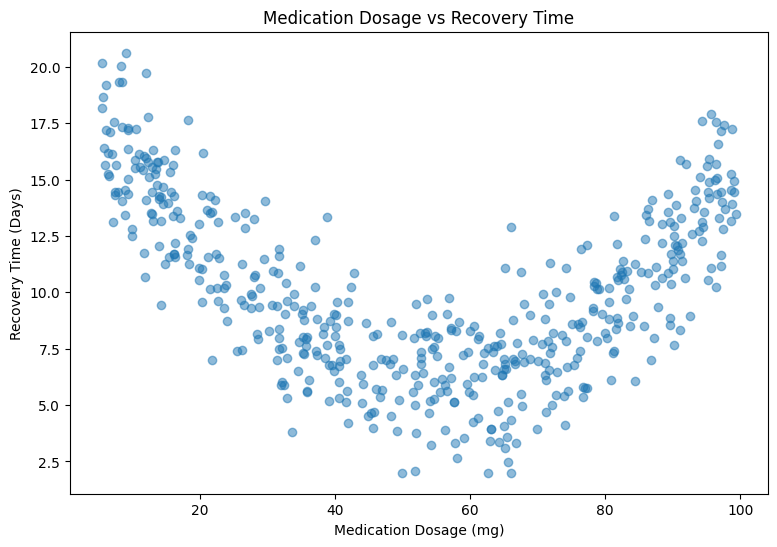

In [8]:



# Cell 15 — Code Cell


# ============================================================
# STEP 7: VISUALIZE DOSAGE VS RECOVERY TIME
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df["dosage_mg"],
    df["recovery_days"],
    alpha=0.5
)

plt.xlabel("Medication Dosage (mg)")
plt.ylabel("Recovery Time (Days)")
plt.title("Medication Dosage vs Recovery Time")

plt.show()

## Graph Interpretation

The relationship is not perfectly straight.

The points may show a curved pattern.

This means Linear Regression may not fully capture the relationship.

Polynomial Regression can fit the curved relationship better.

In [9]:
# ============================================================
# STEP 8: CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df[
    [
        "dosage_mg",
        "age",
        "severity_score",
        "recovery_days"
    ]
].corr()

correlation_matrix

,dosage_mg,age,severity_score,recovery_days
dosage_mg,1.000000,0.032925,-0.071633,-0.223049
age,0.032925,1.000000,0.031763,0.092565
severity_score,-0.071633,0.031763,1.000000,0.099858
recovery_days,-0.223049,0.092565,0.099858,1.000000


## Important Correlation Note

A curved relationship may have weak Pearson correlation even when a strong relationship exists.

For example:

```text
Low dosage  → High recovery time
Medium dosage → Low recovery time
High dosage → High recovery time

Because the relationship changes direction, simple correlation may not describe it properly.

**This is one reason Polynomial Regression is useful.**

In [10]:



# Cell 20 — Code Cell


# ============================================================
# STEP 9: PREPARE INPUT AND TARGET
# ============================================================

# Input variable must be two-dimensional.
X = df[["dosage_mg"]]

# Target variable.
y = df["recovery_days"]

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

Input Shape: (500, 1)
Target Shape: (500,)


In [11]:
# ============================================================
# STEP 10: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 400
Testing Rows: 100


In [12]:
# ============================================================
# STEP 11: TRAIN SIMPLE LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
# ============================================================
# STEP 11: TRAIN SIMPLE LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [16]:
# ============================================================
# STEP 12: PREDICT USING LINEAR REGRESSION
# ============================================================

linear_predictions = linear_model.predict(
    X_test
)

print("First 10 Linear Regression Predictions:")
print(linear_predictions[:10])

First 10 Linear Regression Predictions:
[ 9.75717621  9.36804864 11.04990748 10.66363414  9.15992724 10.44052799
 11.15813061 10.6957443  11.04229618  9.45462715]


In [17]:
# ============================================================
# STEP 13: EVALUATE LINEAR REGRESSION
# ============================================================

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("LINEAR REGRESSION RESULTS")
print("=========================")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

LINEAR REGRESSION RESULTS
MAE : 3.3958
RMSE: 4.0312
R²  : 0.0916


# Part B: Polynomial Regression

Polynomial Regression transforms the original dosage variable into:

```text
Dosage
Dosage²

For degree 2:


---


**Recovery Time = b0 + b1(Dosage) + b2(Dosage²)**

The squared term allows the model to create a curve.

In [18]:



# Cell 26 — Code Cell


# ============================================================
# STEP 14: CREATE POLYNOMIAL REGRESSION MODEL
# ============================================================

# Degree 2 means:
# X and X² will be used.
polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

print("Polynomial Regression pipeline created.")

Polynomial Regression pipeline created.


In [19]:
# ============================================================
# STEP 15: TRAIN POLYNOMIAL REGRESSION MODEL
# ============================================================

polynomial_model.fit(
    X_train,
    y_train
)

print("Polynomial Regression model trained successfully.")

Polynomial Regression model trained successfully.


In [20]:
# ============================================================
# STEP 16: MAKE POLYNOMIAL PREDICTIONS
# ============================================================

polynomial_predictions = polynomial_model.predict(
    X_test
)

print("First 10 Polynomial Regression Predictions:")
print(polynomial_predictions[:10])

First 10 Polynomial Regression Predictions:
[ 6.8634458   9.80493067 14.95818007  9.66211223 12.3996126   7.72041638
 16.88176699 10.00891124 14.83013992  8.93521341]


In [21]:
# ============================================================
# STEP 17: EVALUATE POLYNOMIAL REGRESSION
# ============================================================

polynomial_mae = mean_absolute_error(
    y_test,
    polynomial_predictions
)

polynomial_rmse = mean_squared_error(
    y_test,
    polynomial_predictions
) ** 0.5

polynomial_r2 = r2_score(
    y_test,
    polynomial_predictions
)

print("POLYNOMIAL REGRESSION RESULTS")
print("=============================")
print("MAE :", round(polynomial_mae, 4))
print("RMSE:", round(polynomial_rmse, 4))
print("R²  :", round(polynomial_r2, 4))

POLYNOMIAL REGRESSION RESULTS
MAE : 1.8612
RMSE: 2.2881
R²  : 0.7073


## 7. Evaluation Metrics

### MAE

Mean Absolute Error shows the average difference between actual and predicted recovery time.

```text
Lower MAE is better.

RMSE

Root Mean Squared Error gives greater penalty to larger errors.

```text
Lower RMSE is better.
R² Score



R² measures how much variation in recovery time is explained by the model.

```text
Higher R² is generally better.

In [22]:



# Cell 31 — Code Cell


# ============================================================
# STEP 18: COMPARE LINEAR AND POLYNOMIAL MODELS
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression"
    ],
    "MAE": [
        linear_mae,
        polynomial_mae
    ],
    "RMSE": [
        linear_rmse,
        polynomial_rmse
    ],
    "R2": [
        linear_r2,
        polynomial_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,3.395801,4.031238,0.091576
1,Polynomial Regression,1.861186,2.288101,0.707341


## Model Comparison Interpretation

Polynomial Regression should perform better if:

- Its MAE is lower.
- Its RMSE is lower.
- Its R² is higher.

Reason:

The actual dosage-recovery relationship is curved.

Linear Regression tries to fit a straight line.

Polynomial Regression can fit a curved line.

In [23]:
# ============================================================
# STEP 19: CREATE SMOOTH DOSAGE VALUES FOR CURVE
# ============================================================

dosage_range = np.linspace(
    df["dosage_mg"].min(),
    df["dosage_mg"].max(),
    300
).reshape(-1, 1)

# Convert to DataFrame to preserve feature name.
dosage_range_df = pd.DataFrame(
    dosage_range,
    columns=["dosage_mg"]
)

# Predict with both models.
linear_curve = linear_model.predict(
    dosage_range_df
)

polynomial_curve = polynomial_model.predict(
    dosage_range_df
)

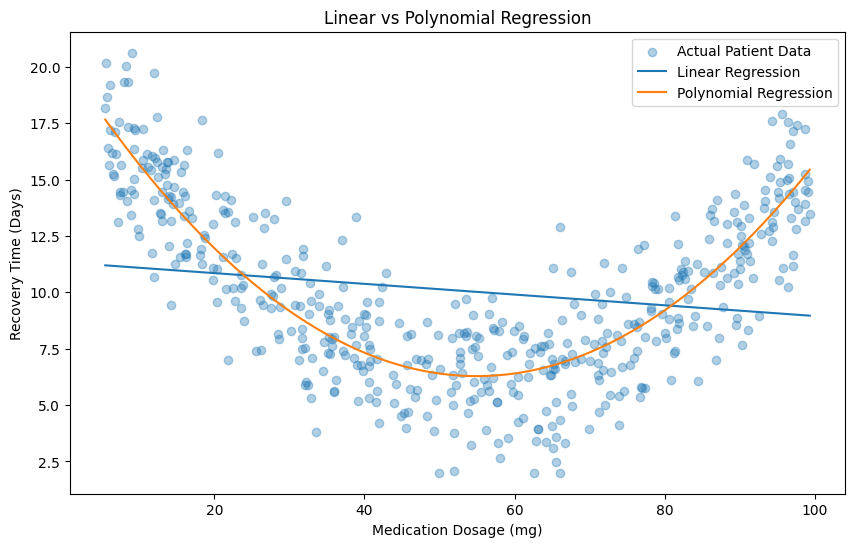

In [24]:
# ============================================================
# STEP 20: VISUALIZE BOTH MODELS
# ============================================================

plt.figure(figsize=(10, 6))

# Actual data points.
plt.scatter(
    df["dosage_mg"],
    df["recovery_days"],
    alpha=0.35,
    label="Actual Patient Data"
)

# Linear Regression line.
plt.plot(
    dosage_range_df["dosage_mg"],
    linear_curve,
    label="Linear Regression"
)

# Polynomial Regression curve.
plt.plot(
    dosage_range_df["dosage_mg"],
    polynomial_curve,
    label="Polynomial Regression"
)

plt.xlabel("Medication Dosage (mg)")
plt.ylabel("Recovery Time (Days)")
plt.title("Linear vs Polynomial Regression")
plt.legend()

plt.show()

## Graph Interpretation

The straight line represents Linear Regression.

The curved line represents Polynomial Regression.

The Polynomial Regression curve should follow the actual pattern more closely.

The graph may show:

```text
Low dosage      → Longer recovery time
Moderate dosage → Shorter recovery time
High dosage     → Recovery time increases again

# Manual Input Prediction

The trained Polynomial Regression model can predict recovery time for new dosage values.

Example inputs:

```text
20 mg
55 mg
90 mg

**Expected behavior:**

* 20 mg may have longer recovery time.
* 55 mg may have shorter recovery time.
* 90 mg may again have longer recovery time.

In [25]:



# Cell 38 — Code Cell


# ============================================================
# STEP 22: CREATE DOSAGE PREDICTION FUNCTION
# ============================================================

def predict_recovery_time(dosage):
    """
    Predict recovery time using both Linear Regression
    and Polynomial Regression.

    This function is for educational demonstration only.
    """

    new_input = pd.DataFrame({
        "dosage_mg": [dosage]
    })

    linear_result = linear_model.predict(
        new_input
    )[0]

    polynomial_result = polynomial_model.predict(
        new_input
    )[0]

    print("Input Dosage:", dosage, "mg")

    print(
        "Linear Regression Prediction:",
        round(linear_result, 2),
        "days"
    )

    print(
        "Polynomial Regression Prediction:",
        round(polynomial_result, 2),
        "days"
    )

In [26]:
# ============================================================
# STEP 23: EXAMPLE 1 - LOW DOSAGE
# ============================================================

predict_recovery_time(
    dosage=20
)

Input Dosage: 20 mg
Linear Regression Prediction: 10.85 days
Polynomial Regression Prediction: 11.96 days


In [27]:
# ============================================================
# STEP 24: EXAMPLE 2 - MODERATE DOSAGE
# ============================================================

predict_recovery_time(
    dosage=55
)

Input Dosage: 55 mg
Linear Regression Prediction: 10.02 days
Polynomial Regression Prediction: 6.28 days


In [28]:
# ============================================================
# STEP 25: EXAMPLE 3 - HIGH DOSAGE
# ============================================================

predict_recovery_time(
    dosage=90
)

Input Dosage: 90 mg
Linear Regression Prediction: 9.19 days
Polynomial Regression Prediction: 12.0 days


## Prediction Interpretation

If the Polynomial Regression model predicts:

```text
20 mg → Higher recovery days
55 mg → Lower recovery days
90 mg → Higher recovery days

then the model has learned the curved relationship.


---


The model is not saying that 55 mg is medically safe or recommended.


---


It only learns the mathematical pattern built into the synthetic dataset.


---

# Cell 43 — Markdown Cell

```markdown
# Optional Advanced Model

The earlier model used only dosage.

A more realistic model can use:

- Dosage
- Age
- Severity score

The target remains:

```text
Recovery Time

# Polynomial transformation can be applied to all numerical inputs.

In [30]:


# Cell 44 — Code Cell

# ============================================================
# STEP 26: PREPARE MULTIPLE INPUT VARIABLES
# ============================================================

advanced_features = [
    "dosage_mg",
    "age",
    "severity_score"
]

X_advanced = df[advanced_features]

y_advanced = df["recovery_days"]

X_adv_train, X_adv_test, y_adv_train, y_adv_test = train_test_split(
    X_advanced,
    y_advanced,
    test_size=0.20,
    random_state=42
)

print("Advanced Training Shape:", X_adv_train.shape)
print("Advanced Testing Shape:", X_adv_test.shape)

Advanced Training Shape: (400, 3)
Advanced Testing Shape: (100, 3)


In [31]:
# ============================================================
# STEP 27: TRAIN ADVANCED POLYNOMIAL REGRESSION MODEL
# ============================================================

advanced_polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

advanced_polynomial_model.fit(
    X_adv_train,
    y_adv_train
)

print("Advanced Polynomial Regression model trained.")

Advanced Polynomial Regression model trained.


In [32]:
# ============================================================
# STEP 28: EVALUATE ADVANCED MODEL
# ============================================================

advanced_predictions = advanced_polynomial_model.predict(
    X_adv_test
)

advanced_mae = mean_absolute_error(
    y_adv_test,
    advanced_predictions
)

advanced_rmse = mean_squared_error(
    y_adv_test,
    advanced_predictions
) ** 0.5

advanced_r2 = r2_score(
    y_adv_test,
    advanced_predictions
)

print("ADVANCED POLYNOMIAL MODEL RESULTS")
print("=================================")
print("MAE :", round(advanced_mae, 4))
print("RMSE:", round(advanced_rmse, 4))
print("R²  :", round(advanced_r2, 4))

ADVANCED POLYNOMIAL MODEL RESULTS
MAE : 1.8095
RMSE: 2.1962
R²  : 0.7304


In [33]:
# ============================================================
# STEP 29: ADVANCED MANUAL PREDICTION
# ============================================================

new_patient = pd.DataFrame([{
    "dosage_mg": 55,
    "age": 45,
    "severity_score": 5.5
}])

advanced_prediction = advanced_polynomial_model.predict(
    new_patient
)[0]

print("New Patient Input")
print("-----------------")
print("Dosage       : 55 mg")
print("Age          : 45 years")
print("Severity     : 5.5")

print("\nPredicted Recovery Time:")
print(round(advanced_prediction, 2), "days")

New Patient Input
-----------------
Dosage       : 55 mg
Age          : 45 years
Severity     : 5.5

Predicted Recovery Time:
6.06 days


# Linear Regression vs Polynomial Regression

| Basis | Linear Regression | Polynomial Regression |
|---|---|---|
| Relationship | Straight line | Curved line |
| Equation | Y = b0 + b1X | Y = b0 + b1X + b2X² |
| Complexity | Simple | More flexible |
| Best For | Linear relationships | Nonlinear curved relationships |
| Risk | Underfitting | Overfitting at high degree |
| Clinical Example | Recovery changes steadily | Recovery improves then worsens |

## Underfitting

A model is underfitted when it is too simple to learn the real pattern.

Example:

```text
Using a straight line for a U-shaped relationship

**Overfitting**

A model is overfitted when it follows noise instead of the general pattern.

**Example:**

Using degree 10 polynomial for a small dataset


---


For this example, degree 2 is appropriate.


---

# Cell 49 — Markdown Cell

```markdown
# Final Interpretation

## What Is the Data?

The dataset contains 500 synthetic patient records.

## What Is the Input?

```text
Medication Dosage

The advanced model also includes:

**Age**

**Severity Score**

**What Is the Target?**

Recovery Time in Days


---

# Cell 50 — Markdown Cell

```markdown
# Short Summary

- Polynomial Regression is used for curved relationships.
- It extends Linear Regression by adding squared or higher-degree terms.
- The independent variable is medication dosage.
- The dependent variable is recovery time.
- The dataset contains 500 synthetic patient records.
- Degree 2 Polynomial Regression is used.
- Linear and Polynomial Regression are compared.
- MAE, RMSE, and R² are used for evaluation.
- Manual input examples demonstrate the trained model.
- The dataset and result are educational only.

In [41]:
# ============================================================
# STEP 29: ADVANCED MANUAL PREDICTION - EXAMPLE 2
# ============================================================

new_patient = pd.DataFrame([{
    "dosage_mg": 20,
    "age": 18,
    "severity_score": 3
}])

advanced_prediction = advanced_polynomial_model.predict(
    new_patient
)[0]

print("New Patient Input")
print("-----------------")
print("Dosage       : " + str(new_patient["dosage_mg"][0]))
print("Age          : " + str(new_patient["age"][0]))
print("Severity     : " + str(new_patient["severity_score"][0]))

print("\nPredicted Recovery Time:")
print(round(advanced_prediction, 2), "days")

New Patient Input
-----------------
Dosage       : 20
Age          : 18
Severity     : 3

Predicted Recovery Time:
11.3 days


In [43]:
# ============================================================
# STEP 29: ADVANCED MANUAL PREDICTION - EXAMPLE 2
# ============================================================

new_patient = pd.DataFrame([{
    "dosage_mg": 20,
    "age": 48,
    "severity_score": 5
}])

advanced_prediction = advanced_polynomial_model.predict(
    new_patient
)[0]

print("New Patient Input")
print("-----------------")
print("Dosage       : " + str(new_patient["dosage_mg"][0]))
print("Age          : " + str(new_patient["age"][0]))
print("Severity     : " + str(new_patient["severity_score"][0]))

print("\nPredicted Recovery Time:")
print(round(advanced_prediction, 2), "days")

New Patient Input
-----------------
Dosage       : 20
Age          : 48
Severity     : 5

Predicted Recovery Time:
11.67 days


In [44]:
# ============================================================
# STEP 29: ADVANCED MANUAL PREDICTION - EXAMPLE 2
# ============================================================

new_patient = pd.DataFrame([{
    "dosage_mg": 90,
    "age": 48,
    "severity_score": 5
}])

advanced_prediction = advanced_polynomial_model.predict(
    new_patient
)[0]

print("New Patient Input")
print("-----------------")
print("Dosage       : " + str(new_patient["dosage_mg"][0]))
print("Age          : " + str(new_patient["age"][0]))
print("Severity     : " + str(new_patient["severity_score"][0]))

print("\nPredicted Recovery Time:")
print(round(advanced_prediction, 2), "days")

New Patient Input
-----------------
Dosage       : 90
Age          : 48
Severity     : 5

Predicted Recovery Time:
11.73 days


In [45]:
## overfitting problem
## lollllllllllllllllllllllll